In [1]:
from scipy.stats import yeojohnson
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
housing = fetch_california_housing()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

In [2]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [3]:
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


1. Exploratory Data Analysis


In [4]:
df.shape

(20640, 9)

In [5]:
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [6]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [7]:
df.nunique()

MedInc         12928
HouseAge          52
AveRooms       19392
AveBedrms      14233
Population      3888
AveOccup       18841
Latitude         862
Longitude        844
MedHouseVal     3842
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


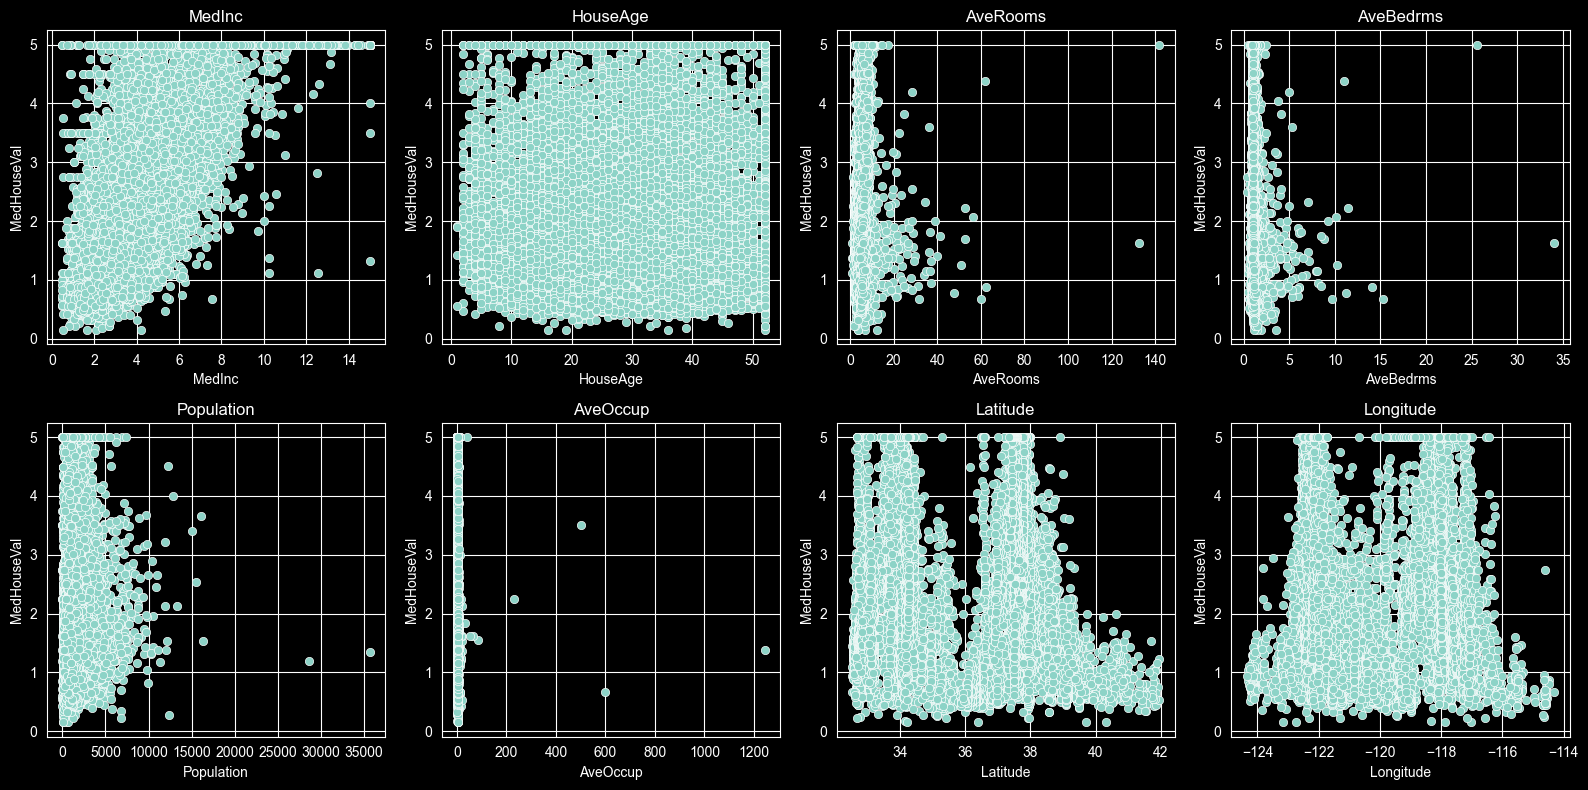

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(df.columns[:-1]):
    sns.scatterplot(x=df[feature], y=df['MedHouseVal'], ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()


On the MedInc (median income) graph, the dots form a clear diagonal line, sloping upward and to the right. This indicates a strong correlation: the wealthier the neighborhood, the more expensive the houses in it.

In the AveRooms graph, the majority of the data points are clustered on the left (1-6 rooms), but there's a long tail to the right. Data points with 20, 50, or 140 rooms have average or low house prices. These aren't mansions, but rather dorms or hotels, which are included in the housing statistics.

The Latitude and Longitude graphs show the geographic distribution of prices. The Latitude graph shows two clear price peaks: around 34° and around 37-38°. Moving north, above 40°, prices drop sharply.

The Longitude graph shows that the most expensive properties are concentrated on the left (around -118°), and the price per square meter decreases as you move to the right.

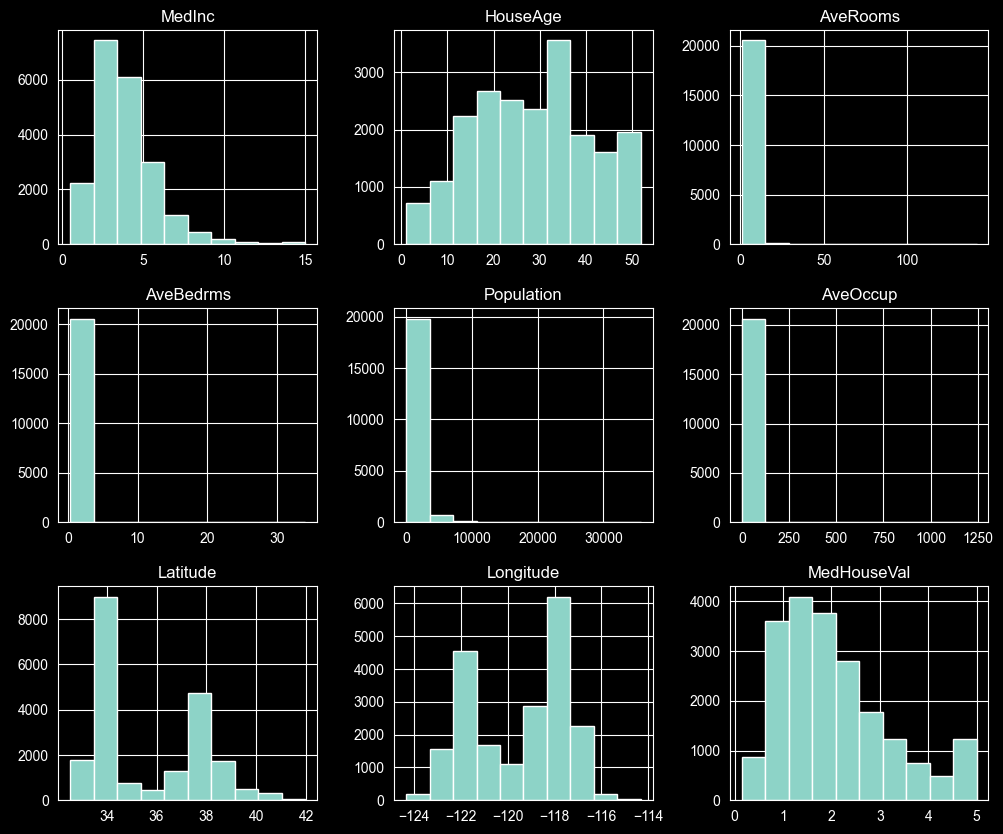

In [12]:
df.hist(figsize=(12, 10))
plt.show()

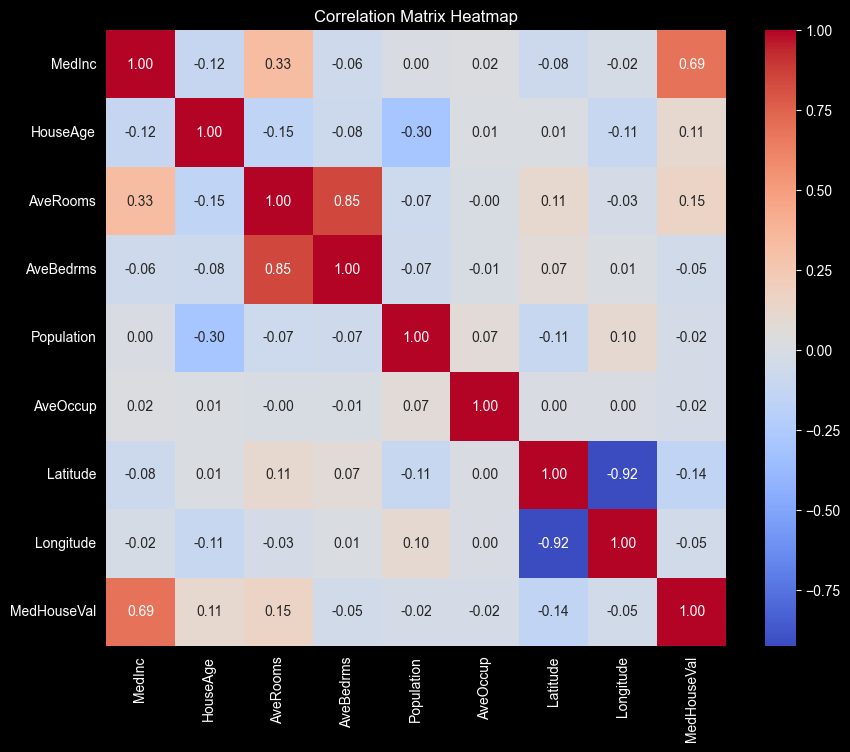

In [13]:
corr_mat = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

AveRooms and AveBedrms (0.85).
A strong positive relationship between the total number of rooms and the number of bedrooms. This is logical: the larger the house, the more bedrooms it has.

MedInc and MedHouseVal (0.69).
The most significant relationship with the target variable. Neighborhood income is the best predictor of home value. The higher the median income, the more expensive the houses.

HouseAge and Population (-0.30).
A moderate negative relationship. Neighborhoods with older houses tend to have fewer residents.

Latitude and Longitude (-0.92).
This is the strongest relationship in the entire table, a virtually perfect inverse relationship. The higher the latitude (northern), the further east the longitude becomes.


2. Multiple Regression Model


In [16]:
x = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

In [17]:
X_train,X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=10)
print(X_train.shape, X_test.shape)


(16512, 8) (4128, 8)


In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print(f"Test data r-squared: {lr.score(X_test, y_test)}")
print(f"Train data r-squared: {lr.score(X_train, y_train)}")
inter = lr.intercept_
print(f"Intercept: {inter}")

Test data r-squared: 0.6009790143129101
Train data r-squared: 0.607404930502105
Intercept: -37.48696576537289


The trained linear regression showed a coefficient of determination (R²) of about 0.60 on the test data, which means that the model explains 60% of the variation in house prices, training (0.607) and test (0.601) samples indicates the absence of overfitting.

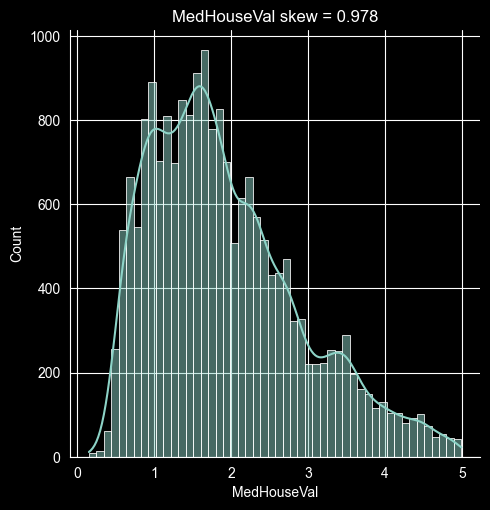

In [19]:
df_cut = df[df['MedHouseVal'] < 5]
sns.displot(df_cut['MedHouseVal'], kde=True)
plt.title(f"MedHouseVal skew = {df['MedHouseVal'].skew():.3f}")
plt.show()

In [20]:
sqrt_medhouse = np.log1p(df['MedHouseVal'])

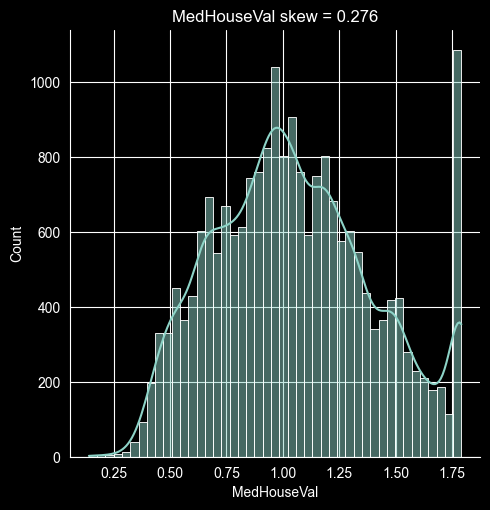

In [21]:
sns.displot(sqrt_medhouse, kde=True)
plt.title(f"MedHouseVal skew = {sqrt_medhouse.skew():.3f}")
plt.show()

In [22]:
sqrt_medhouse.mean()

np.float64(1.0561463885819422)

In [23]:
sqrt_medhouse.median()

np.float64(1.0285474142198225)

In [24]:
x = df.drop(columns=['MedHouseVal'])
y = np.sqrt(df['MedHouseVal'])
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)
print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


In [25]:
regr = LinearRegression()
regr.fit(X_train, y_train)
print(f"Test data r-squared: {regr.score(X_test, y_test)}")
print(f"Train data r-squared: {regr.score(X_train, y_train)}")
inter = regr.intercept_
print(f"Intercept: {inter}")
coef_df = pd.DataFrame(data=regr.coef_, index=X_train.columns, columns=['coefficients'])
coef_df.round(4)

Test data r-squared: 0.6137073512598744
Train data r-squared: 0.6249272078594833
Intercept: -14.012480968503738


,coefficients
MedInc,0.1381
HouseAge,0.0024
AveRooms,-0.0279
AveBedrms,0.1830
Population,0.0000
AveOccup,-0.0016
Latitude,-0.1723
Longitude,-0.1747


In [26]:
X_incl_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_incl_const)
results = model.fit()
pd.DataFrame({'coefficients': results.params, 'p_value': round(results.pvalues, 3)})

,coefficients,p_value
const,-14.012481,0.0
MedInc,0.138066,0.0
HouseAge,0.002395,0.0
AveRooms,-0.027879,0.0
AveBedrms,0.182977,0.0
Population,0.000002,0.2
AveOccup,-0.001592,0.0
Latitude,-0.172320,0.0
Longitude,-0.174682,0.0


In [27]:
vif = [variance_inflation_factor(exog=X_incl_const.values, exog_idx=i) for i in range(X_incl_const.shape[1])]
pd.DataFrame({'coef_name': X_incl_const.columns,'vif': np.around(vif,2)})

,coef_name,vif
0,const,17168.65
1,MedInc,2.47
2,HouseAge,1.24
3,AveRooms,8.87
4,AveBedrms,7.54
5,Population,1.14
6,AveOccup,1.01
7,Latitude,9.38
8,Longitude,9.04


In this table, three features have high VIFs: AveRooms (8.87), AveBedrms (7.54), and Latitude and Longitude (around 9). Value are greater than 5 indicate strong interdependence—these features overlap and interfere with the model's stability.

In [28]:
org_coef = pd.DataFrame({'corf': results.params, 'p_value': round(results.pvalues, 3)})

In [29]:
df['bedroom_ratio'] = df['AveBedrms'] / df['AveRooms']

In [30]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal', 'bedroom_ratio'],
      dtype='str')

In [31]:
X_incl_const = sm.add_constant(X_train)
X_incl_const = X_incl_const.drop(['AveBedrms', 'AveRooms'], axis=1)
vif1 = [variance_inflation_factor(exog=X_incl_const.values, exog_idx=i) for i in range(X_incl_const.shape[1])]
pd.DataFrame({'coef_name': X_incl_const.columns,'vif': np.around(vif1,2)})

,coef_name,vif
0,const,15733.95
1,MedInc,1.11
2,HouseAge,1.24
3,Population,1.13
4,AveOccup,1.01
5,Latitude,8.17
6,Longitude,8.16


Then I removed AveBedrms and AveRooms, replacing them with a single new feature, bedroom_ratio (proportion of bedrooms). I recalculated the VIFs for the remaining features. For MedInc, the value dropped from 2.47 to 1.11—excellent. For geocoordinates, the VIF decreased slightly (from 9.38 to 8.17), but still remained high—this is normal for latitude and longitude.

In [32]:
model = sm.OLS(y_train, X_incl_const)
results = model.fit()
coef_new = pd.DataFrame({'coef': results.params, 'p_value': round(results.pvalues, 3)})

In [33]:
pd.DataFrame({'coef': results.params, 'p_value': round(results.pvalues, 3)})

,coef,p_value
const,-14.062845,0.000
MedInc,0.122744,0.000
HouseAge,0.002358,0.000
Population,0.000001,0.509
AveOccup,-0.001639,0.000
Latitude,-0.176168,0.000
Longitude,-0.177182,0.000


r-squared is:  0.5475451336341091


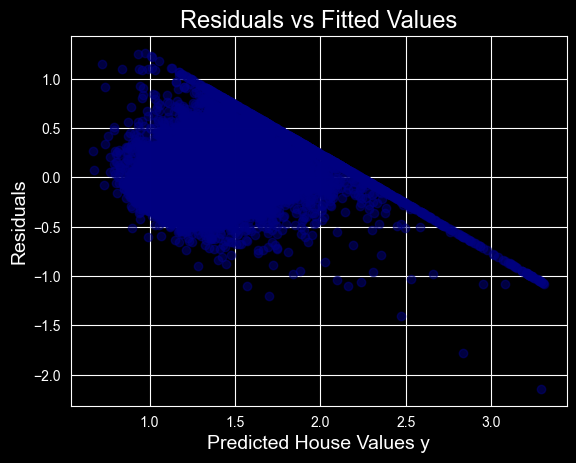

In [34]:
Y = np.sqrt(df['MedHouseVal'])
X = df.drop(['MedHouseVal','AveBedrms', 'Longitude'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
reg = LinearRegression()
reg.fit(X_train, y_train)
X_incl_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_incl_const)
results = model.fit()
print('r-squared is: ', results.rsquared)
plt.scatter(x = results.fittedvalues, y = results.resid, c = 'navy', alpha = 0.5)
plt.xlabel('Predicted House Values y', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.title('Residuals vs Fitted Values', fontsize=17)
plt.show()

The graph shows how wrong the model is. On the left, where houses are cheaper, the dots are clustered around zero, meaning it's guessing the price almost perfectly. But on the right, where houses are more expensive, everything is scattered in different directions, with especially many dots falling (heteroscedasticity), indicating the model is significantly underestimating the actual price.

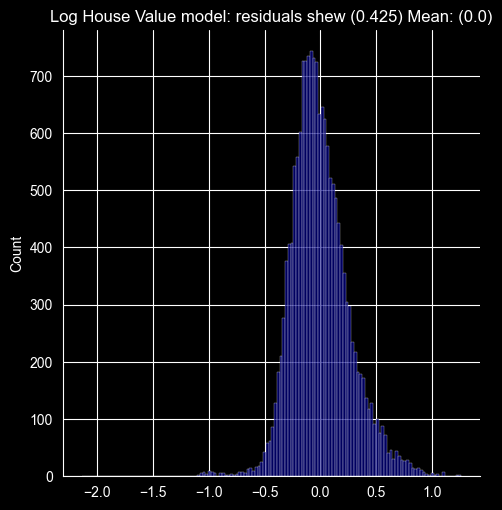

In [35]:
resid_mean = round(results.resid.mean(),3)
resid_skew = round(results.resid.skew(),3)
sns.displot(results.resid, color = 'navy')
plt.title(f"Log House Value model: residuals shew ({resid_skew}) Mean: ({resid_mean})")
plt.show()

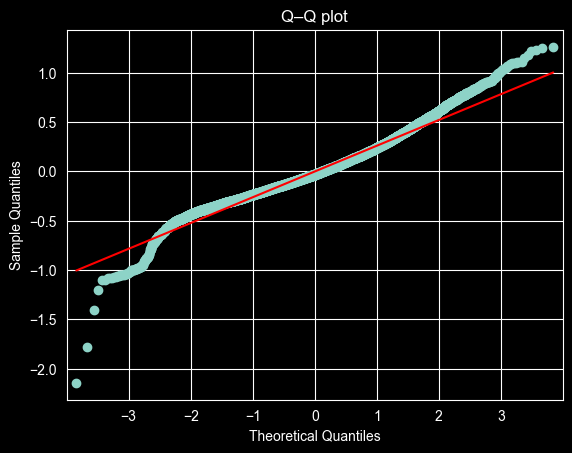

In [36]:
sm.qqplot(results.resid, line='s')
plt.title("Q–Q plot")
plt.show()

In [37]:
y_pred_test = reg.predict(X_test)
y_pred_train = reg.predict(X_train)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))


print(f"Test R-square: {reg.score(X_test, y_test):.3f}")
print(f"Train R-square: {reg.score(X_train, y_train):.3f}")
print(f"Test RMSE: {np.exp(rmse):.3f}")
print(f"Test mse: {np.exp(mse):.3f}")

Test R-square: 0.528
Train R-square: 0.548
Test RMSE: 1.304
Test mse: 1.073
